# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The India Cities Dataset](https://www.kaggle.com/datasets/vishalbaraiya1014/india-environmental-dataset-2021-2025)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

/kaggle/input/datasets/vishalbaraiya1014/india-environmental-dataset-2021-2025/india_cities_dataset_2021_2025.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('india_cities_dataset_2021_2025.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,City,State,Latitude,Longitude,Year,Month,NDVI,NDBI,NDWI,Elevation (m),LST (°C)
0,Mumbai,Mahārāshtra,19.0758,72.8775,2021,January,0.0371,0.0316,-0.0858,5,34.57
1,Kolkata,West Bengal,22.5675,88.3700,2021,January,0.0715,0.0436,-0.1684,6,26.96
2,Delhi,Delhi,28.6600,77.2300,2021,January,0.0814,-0.0198,-0.0839,219,18.27
3,Chennai,Tamil Nādu,13.0825,80.2750,2021,January,0.0603,0.1507,-0.0752,9,31.32
4,Bangalore,Karnātaka,12.9791,77.5913,2021,January,0.2864,-0.0184,-0.3224,924,28.66


## last Five row

In [4]:
df.tail()

,City,State,Latitude,Longitude,Year,Month,NDVI,NDBI,NDWI,Elevation (m),LST (°C)
5582,Kimsar,Jammu and Kashmīr,34.5000,74.5333,2025,December,0.2841,-0.4102,-0.2829,3058,-2.17
5583,Sinduri,Himāchal Pradesh,30.7167,77.1500,2025,December,0.3096,0.0403,-0.4030,943,14.89
5584,Gorakhpur,Uttar Pradesh,26.7611,83.3667,2025,December,0.1634,-0.0058,-0.2046,84,20.26
5585,Guntur,Andhra Pradesh,16.3000,80.4500,2025,December,0.1503,0.0288,-0.1555,34,27.26
5586,Karaikandi,Assam,24.8309,92.6143,2025,December,0.7778,-0.2929,-0.6848,20,21.41


## Shape of our dataset

In [5]:
df.shape

(5587, 11)

## List out all columns

In [6]:
df.columns

Index(['City', 'State', 'Latitude', 'Longitude', 'Year', 'Month', 'NDVI',
       'NDBI', 'NDWI', 'Elevation (m)', 'LST (°C)'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

City              object
State             object
Latitude         float64
Longitude        float64
Year               int64
Month             object
NDVI             float64
NDBI             float64
NDWI             float64
Elevation (m)      int64
LST (°C)         float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5587 entries, 0 to 5586
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   City           5587 non-null   object 
 1   State          5587 non-null   object 
 2   Latitude       5587 non-null   float64
 3   Longitude      5587 non-null   float64
 4   Year           5587 non-null   int64  
 5   Month          5587 non-null   object 
 6   NDVI           5587 non-null   float64
 7   NDBI           5587 non-null   float64
 8   NDWI           5587 non-null   float64
 9   Elevation (m)  5587 non-null   int64  
 10  LST (°C)       5587 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 480.3+ KB


## Check Null Value

In [9]:
df.isnull().sum()

City             0
State            0
Latitude         0
Longitude        0
Year             0
Month            0
NDVI             0
NDBI             0
NDWI             0
Elevation (m)    0
LST (°C)         0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Latitude,Longitude,Year,NDVI,NDBI,NDWI,Elevation (m),LST (°C)
count,5587.000000,5587.000000,5587.000000,5587.000000,5587.000000,5587.000000,5587.000000,5587.000000
mean,22.842526,78.585149,2022.990335,0.218733,-0.006963,-0.238766,297.653123,30.759429
std,6.677152,4.552711,1.414054,0.193526,0.131042,0.177594,402.131095,6.355787
min,8.487500,70.070000,2021.000000,-0.230500,-0.798300,-0.809000,0.000000,-9.280000
25%,18.627800,75.848600,2022.000000,0.082600,-0.076950,-0.336050,63.000000,27.475000
50%,23.683300,77.730000,2023.000000,0.163100,0.016400,-0.208700,219.000000,31.610000
75%,28.660000,80.109800,2024.000000,0.308250,0.082200,-0.124000,337.000000,35.240000
max,34.500000,92.614300,2025.000000,0.895100,0.310300,0.212100,3058.000000,48.600000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

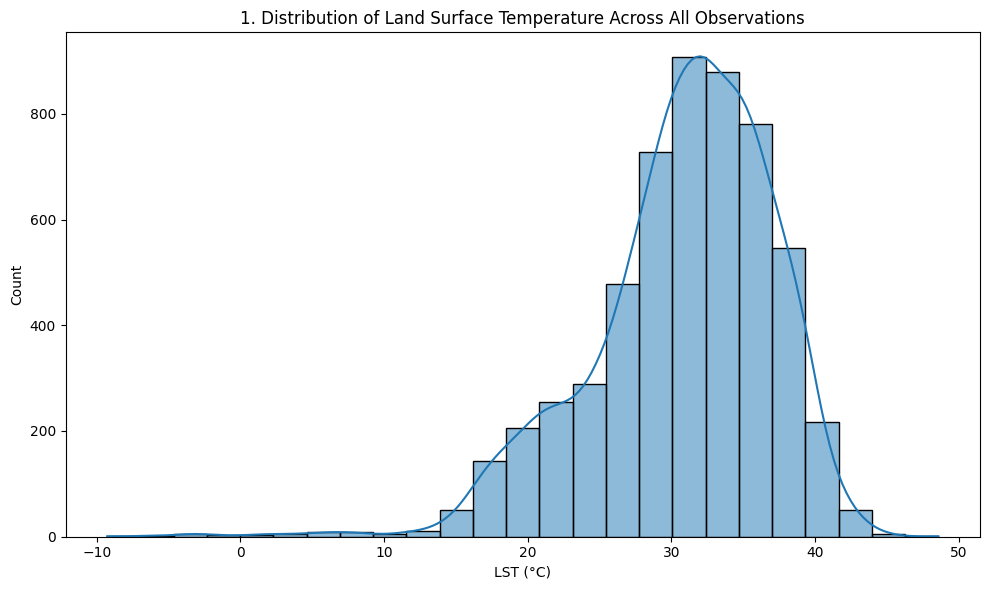

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='LST (°C)', bins=25, kde=True)
plt.title(f'{plot_no}. Distribution of Land Surface Temperature Across All Observations')
show_fig()
plot_no += 1

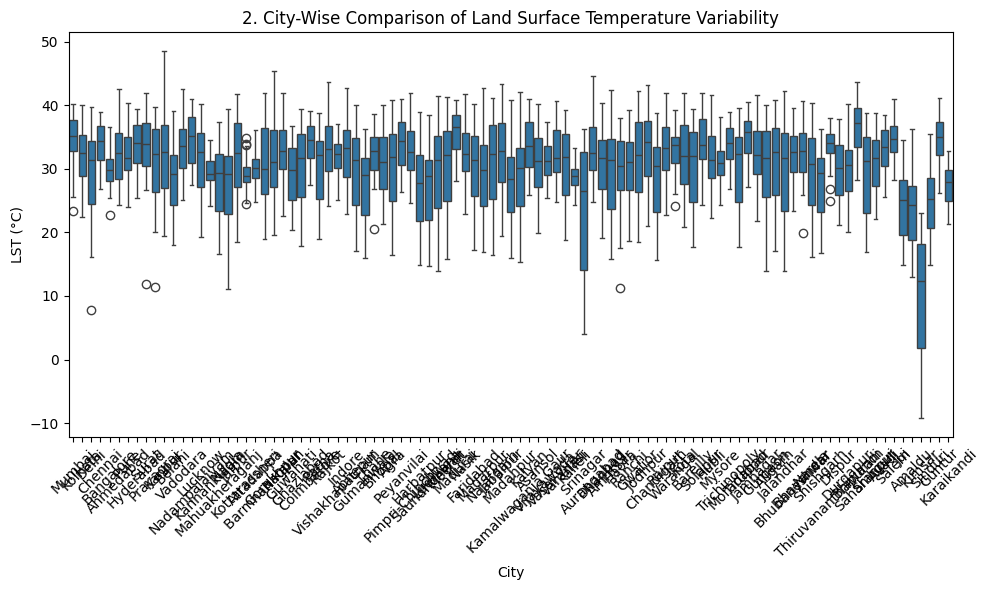

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='City', y='LST (°C)')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. City-Wise Comparison of Land Surface Temperature Variability')
show_fig()
plot_no += 1

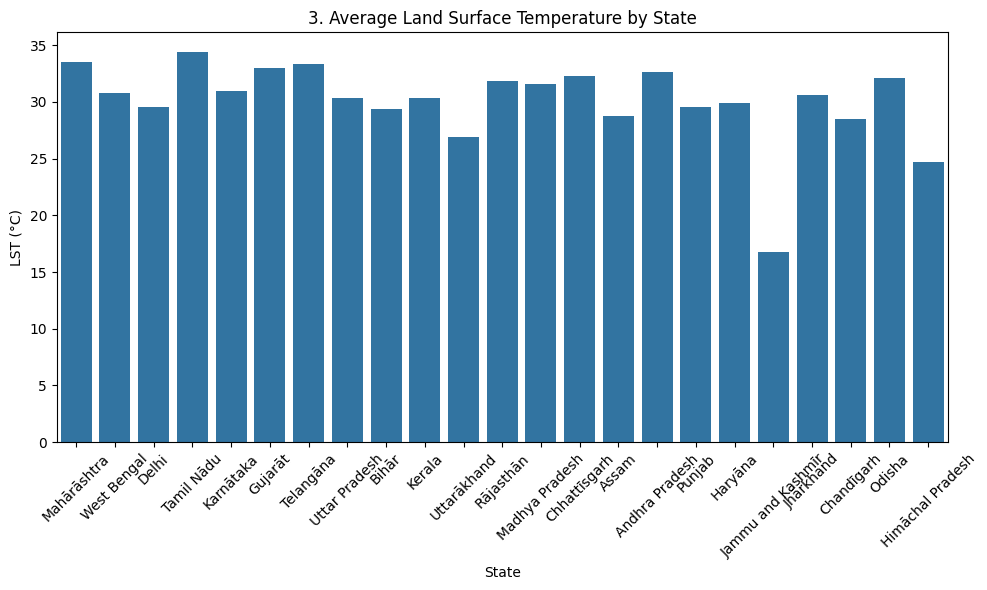

In [15]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='State', y='LST (°C)', estimator='mean', errorbar=None)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average Land Surface Temperature by State')
show_fig()
plot_no += 1

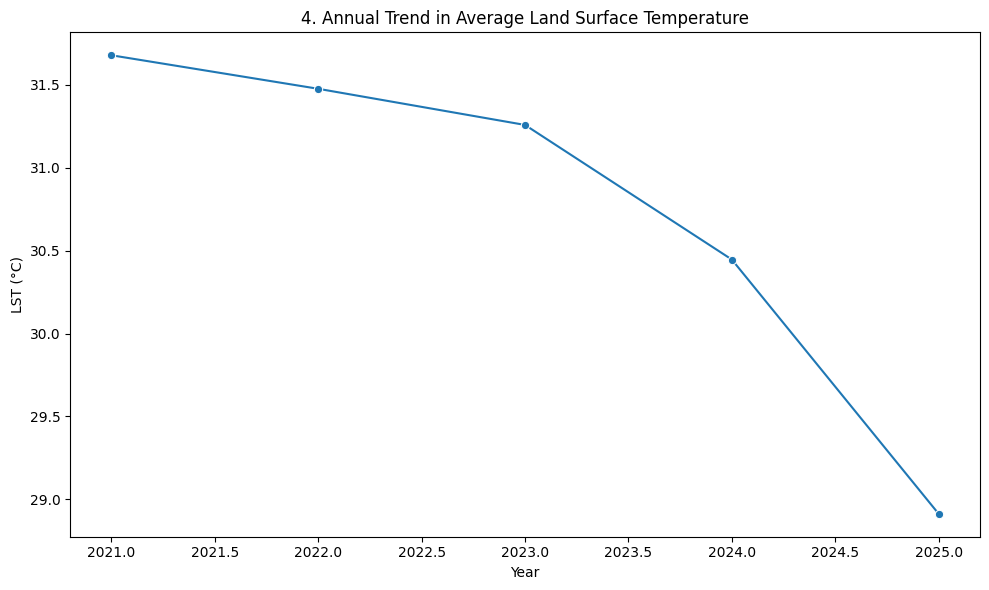

In [16]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Year', y='LST (°C)', marker='o', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Annual Trend in Average Land Surface Temperature')
show_fig()
plot_no += 1

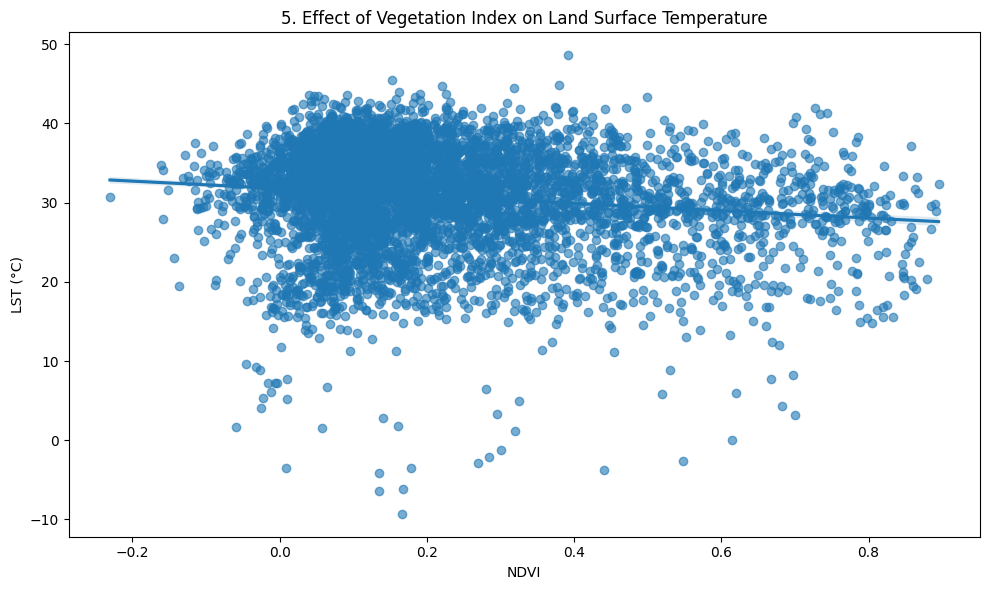

In [17]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='NDVI', y='LST (°C)', scatter_kws={'alpha':0.6})
plt.title(f'{plot_no}. Effect of Vegetation Index on Land Surface Temperature')
show_fig()
plot_no += 1

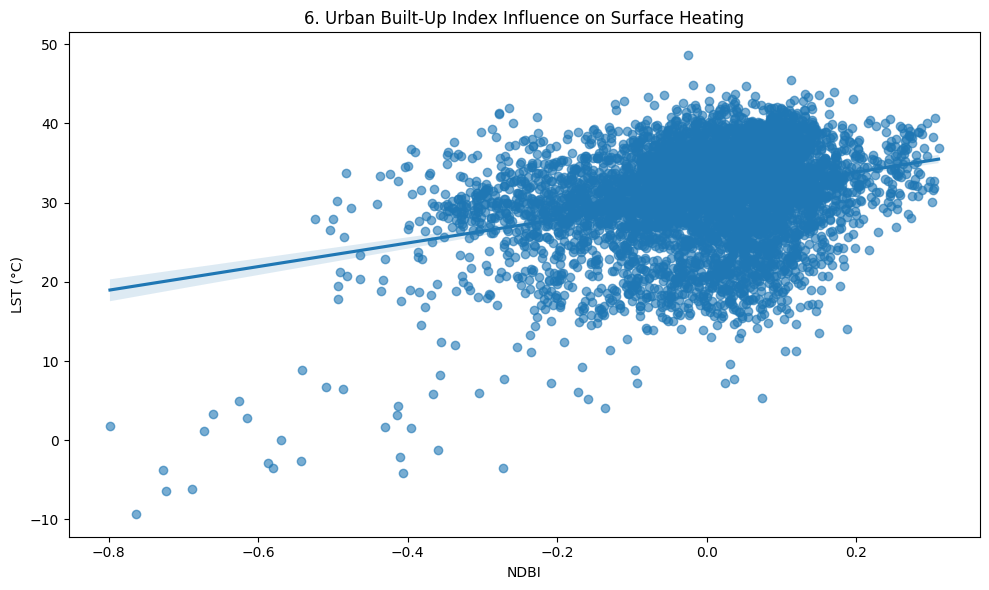

In [18]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='NDBI', y='LST (°C)', scatter_kws={'alpha':0.6})
plt.title(f'{plot_no}. Urban Built-Up Index Influence on Surface Heating')
show_fig()
plot_no += 1

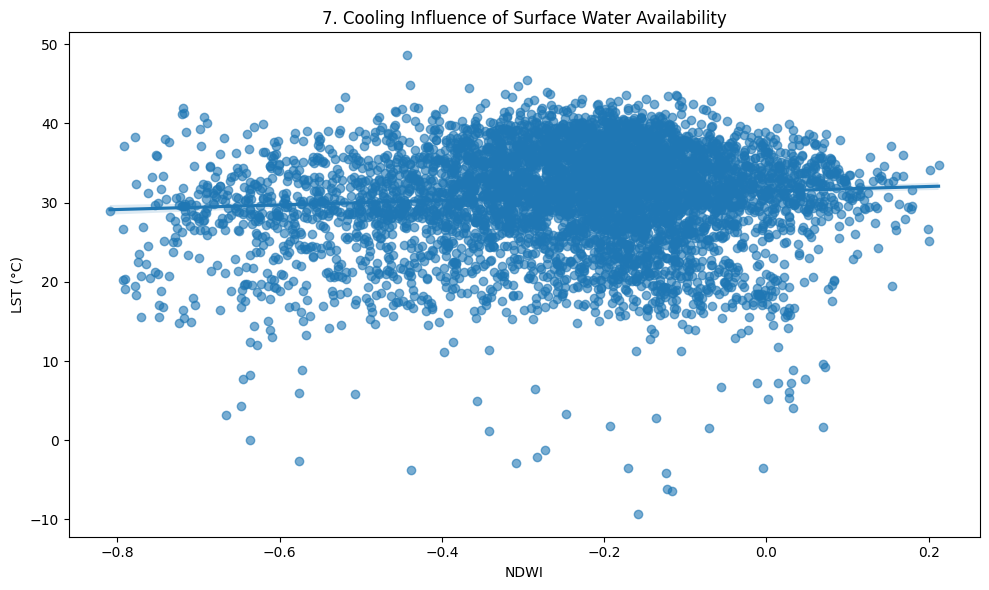

In [19]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='NDWI', y='LST (°C)', scatter_kws={'alpha':0.6})
plt.title(f'{plot_no}. Cooling Influence of Surface Water Availability')
show_fig()
plot_no += 1

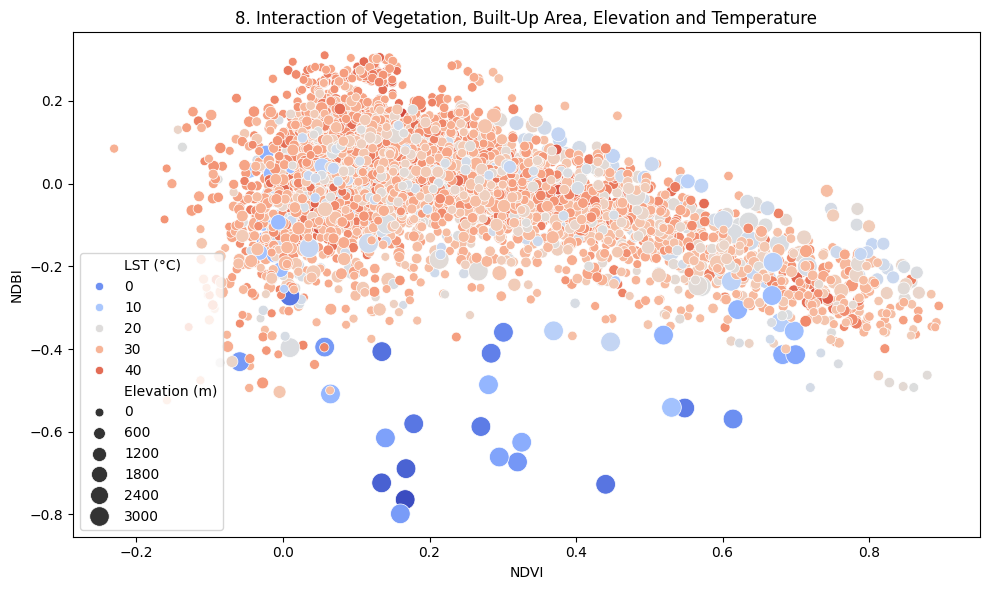

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='NDVI', y='NDBI', hue='LST (°C)', size='Elevation (m)', sizes=(40,200), palette='coolwarm')
plt.title(f'{plot_no}. Interaction of Vegetation, Built-Up Area, Elevation and Temperature')
show_fig()
plot_no += 1

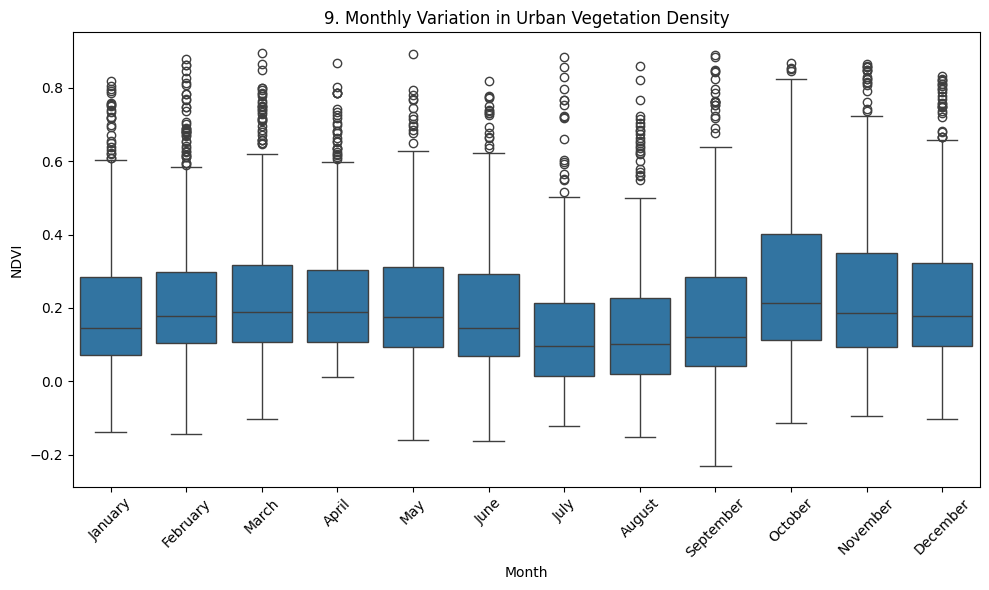

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Month', y='NDVI', order=['January','February','March','April','May','June','July','August','September','October','November','December'])
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Monthly Variation in Urban Vegetation Density')
show_fig()
plot_no += 1

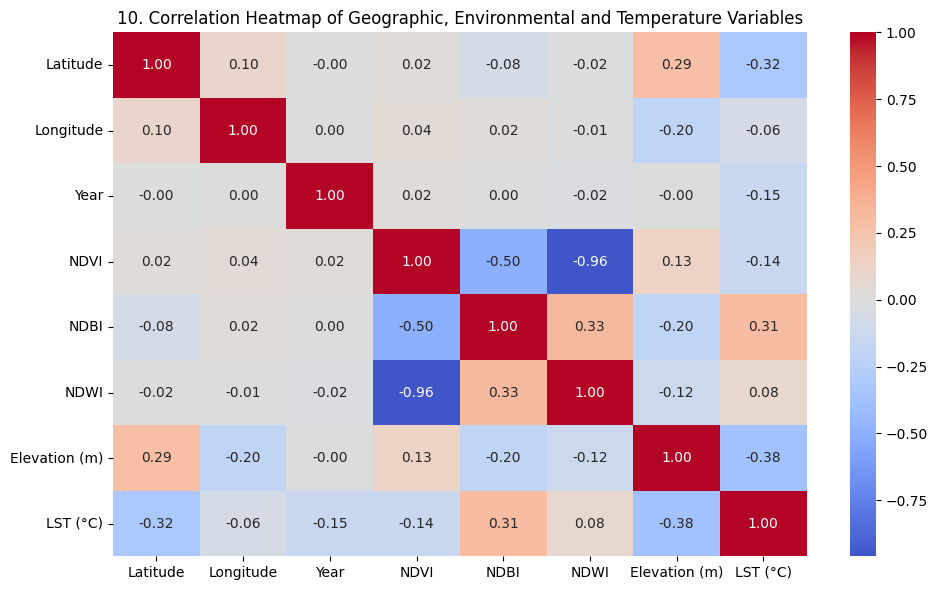

In [22]:
corr = df.select_dtypes(include='number').corr()
fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title(f'{plot_no}. Correlation Heatmap of Geographic, Environmental and Temperature Variables')
show_fig()
plot_no += 1

# Model Train

## remove rows with missing target values

In [23]:
df.dropna(subset=['LST (°C)'], inplace=True)

## select target column

In [24]:
target = 'LST (°C)'

## create input and output data

In [25]:
X = df.drop(columns=[target])
y = df[target]

## identify numerical columns

In [26]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()

## identify categorical columns

In [27]:
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

## create preprocessing pipeline

In [28]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

## create gradient boosting model

In [29]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        min_samples_split=5,
        min_samples_leaf=3,
        random_state=42
    ))
])

## split data into training and testing sets

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

## train the model

In [31]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Latitude', 'Longitude',
                                                   'Year', 'NDVI', 'NDBI',
                                                   'NDWI', 'Elevation (m)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['City', 'State',
                                                   'Month'])])),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=4,
                                           min_samples_leaf=3,
                                           min_samples_split=5,
                                           n_estimators=300,
                                           random_state=42))])

## predict test data

In [32]:
y_pred = model.predict(X_test)

## calculate model performance

In [33]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

## print model performance

In [34]:
print(f"Model Accuracy (R² Score): {round(r2 * 100)}%")
print(f"Mean Absolute Error: {mae:.2f} °C")
print(f"Root Mean Squared Error: {rmse:.2f} °C")

Model Accuracy (R² Score): 91%
Mean Absolute Error: 1.38 °C
Root Mean Squared Error: 1.90 °C


## create perfect prediction reference line

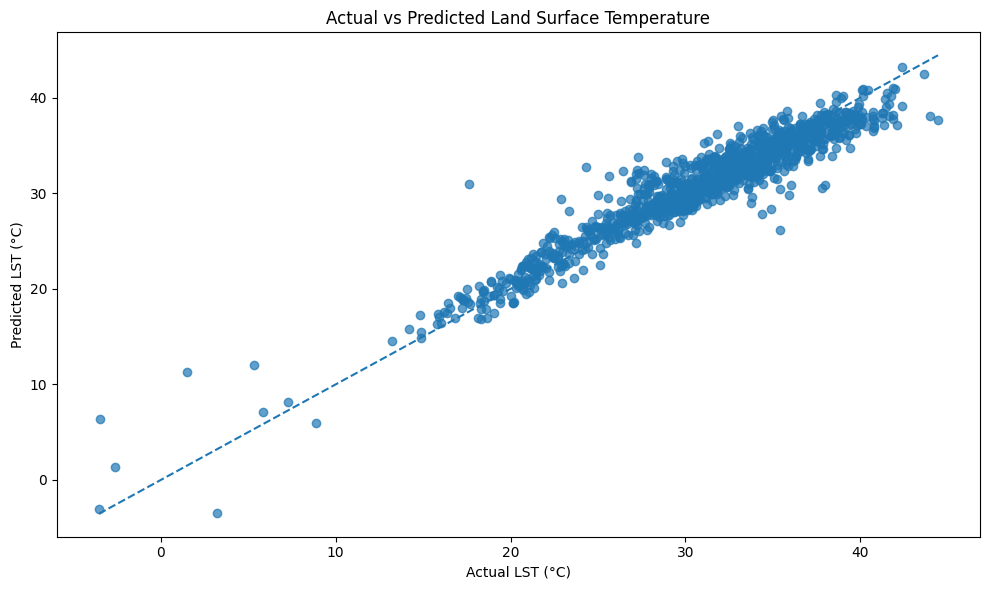

In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle='--')

plt.xlabel('Actual LST (°C)')
plt.ylabel('Predicted LST (°C)')
plt.title('Actual vs Predicted Land Surface Temperature')
plt.tight_layout()
plt.show()